# Модель Лотки–Вольтерра
## Популяционная динамика: «хищник–жертва»


---

### Биологический смысл

Модель Лотки–Вольтерра описывает взаимодействие двух популяций:
- **Жертвы** (например, зайцы) — растут без ограничений при отсутствии хищников
- **Хищники** (например, лисы) — выживают только за счёт поедания жертв

Это классический пример нелинейной динамической системы с автоколебаниями.

---

### Уравнения модели

$$\frac{dx}{dt} = \alpha x - \beta x y$$

$$\frac{dy}{dt} = \delta x y - \gamma y$$

Где:
- $x(t)$ — численность жертв
- $y(t)$ — численность хищников
- $\alpha$ — скорость естественного прироста жертв (рождаемость)
- $\beta$ — скорость выедания жертв хищниками (эффективность охоты)
- $\delta$ — скорость прироста хищников за счёт поедания жертв
- $\gamma$ — естественная смертность хищников

---

### Равновесные состояния

Система имеет два равновесия:
1. **Тривиальное:** $x^* = 0,\ y^* = 0$ — вымирание обеих популяций (неустойчивое)
2. **Нетривиальное:** $x^* = \gamma/\delta,\ y^* = \alpha/\beta$ — устойчивый центр (нейтральная устойчивость)

Траектории в фазовом пространстве — **замкнутые орбиты** вокруг нетривиального равновесия. Это и есть автоколебания.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

## 1. Базовая модель

Зададим параметры и правую часть системы ОДУ.

In [2]:
def lotka_volterra(t, state, alpha, beta, delta, gamma):
    """Правая часть системы Лотки-Вольтерра."""
    x, y = state
    dxdt = alpha * x - beta * x * y      # жертвы
    dydt = delta * x * y - gamma * y     # хищники
    return [dxdt, dydt]

# Параметры (биологически разумные значения)
alpha = 1.0   # рождаемость жертв
beta  = 0.1   # эффективность охоты
delta = 0.075 # конверсия жертвы в потомство хищника
gamma = 1.5   # смертность хищников

# Начальные условия: 10 жертв, 5 хищников
x0, y0 = 10, 5
t_span = (0, 60)
t_eval = np.linspace(*t_span, 3000)

sol = solve_ivp(
    lotka_volterra, t_span, [x0, y0],
    args=(alpha, beta, delta, gamma),
    t_eval=t_eval, method='RK45', rtol=1e-8
)

x_sol, y_sol = sol.y

x_eq = gamma / delta
y_eq = alpha / beta
print(f"Равновесие: x* = {x_eq:.1f} жертв, y* = {y_eq:.1f} хищников")

Равновесие: x* = 20.0 жертв, y* = 10.0 хищников


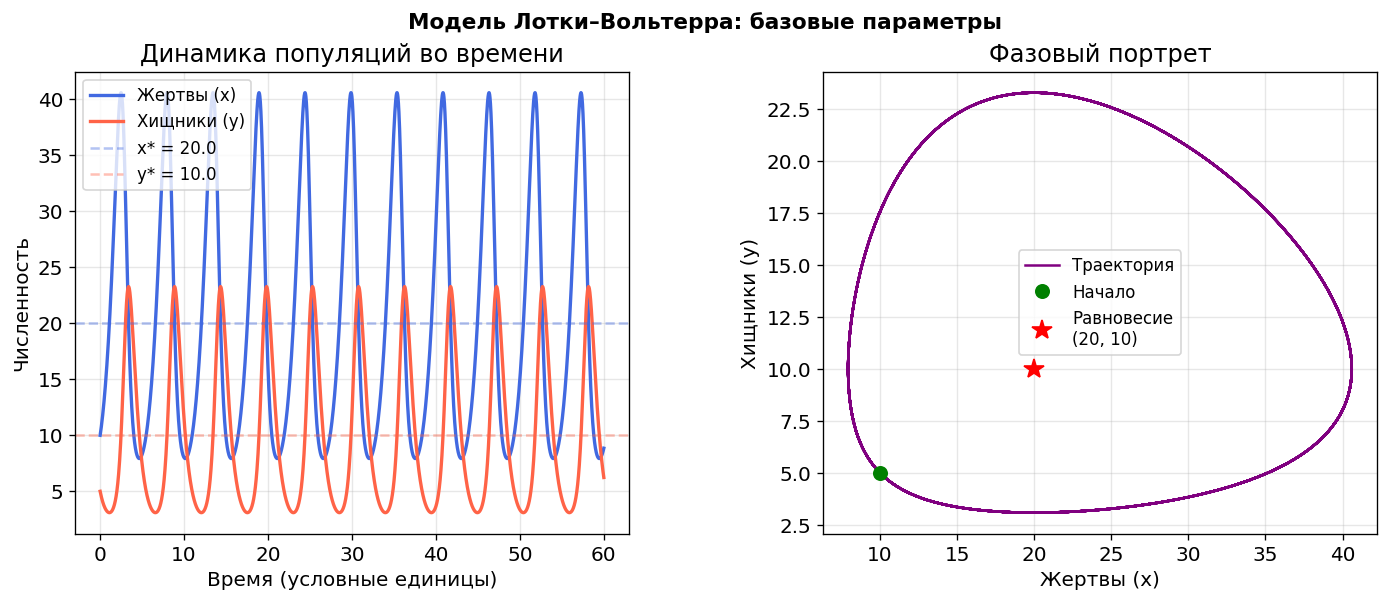

In [3]:
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot(sol.t, x_sol, label='Жертвы (x)', color='royalblue', lw=2)
ax1.plot(sol.t, y_sol, label='Хищники (y)', color='tomato', lw=2)
ax1.axhline(x_eq, color='royalblue', ls='--', alpha=0.4, label=f'x* = {x_eq:.1f}')
ax1.axhline(y_eq, color='tomato',    ls='--', alpha=0.4, label=f'y* = {y_eq:.1f}')
ax1.set_xlabel('Время (условные единицы)')
ax1.set_ylabel('Численность')
ax1.set_title('Динамика популяций во времени')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(x_sol, y_sol, color='purple', lw=1.5, label='Траектория')
ax2.plot(x0, y0, 'go', ms=8, label='Начало')
ax2.plot(x_eq, y_eq, 'r*', ms=12, label=f'Равновесие\n({x_eq:.0f}, {y_eq:.0f})')
ax2.set_xlabel('Жертвы (x)')
ax2.set_ylabel('Хищники (y)')
ax2.set_title('Фазовый портрет')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Модель Лотки–Вольтерра: базовые параметры', fontsize=13, fontweight='bold')
plt.savefig('base_model.png', bbox_inches='tight')
plt.show()

## 2. Вариация параметров

Исследуем, как изменение параметров влияет на динамику системы.

### 2.1 Влияние начальных условий

Различные начальные условия дают разные орбиты, но все они замкнуты — фазовый портрет заполнен концентрическими кривыми.

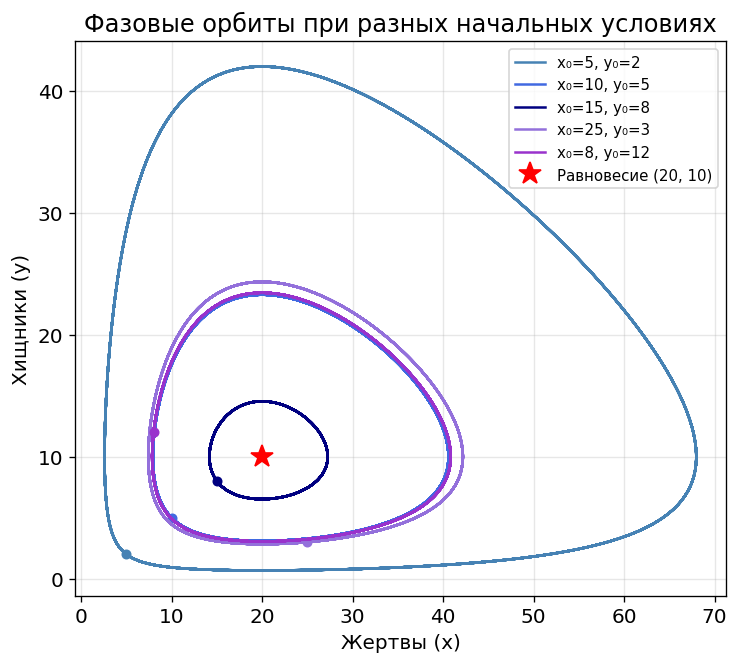

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

initial_conditions = [
    (5,  2,  'steelblue'),
    (10, 5,  'royalblue'),
    (15, 8,  'navy'),
    (25, 3,  'mediumpurple'),
    (8,  12, 'darkorchid'),
]

for x0_i, y0_i, color in initial_conditions:
    sol_i = solve_ivp(
        lotka_volterra, (0, 80), [x0_i, y0_i],
        args=(alpha, beta, delta, gamma),
        t_eval=np.linspace(0, 80, 4000), rtol=1e-8
    )
    ax.plot(sol_i.y[0], sol_i.y[1], color=color, lw=1.5,
            label=f'x₀={x0_i}, y₀={y0_i}')
    ax.plot(x0_i, y0_i, 'o', color=color, ms=5)

ax.plot(x_eq, y_eq, 'r*', ms=14, zorder=5, label=f'Равновесие ({x_eq:.0f}, {y_eq:.0f})')
ax.set_xlabel('Жертвы (x)')
ax.set_ylabel('Хищники (y)')
ax.set_title('Фазовые орбиты при разных начальных условиях')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.savefig('phase_orbits.png', bbox_inches='tight')
plt.show()

### 2.2 Влияние параметра α (рождаемость жертв)

Увеличение α сдвигает равновесие хищников вверх ($y^* = \alpha/\beta$) и увеличивает период колебаний.

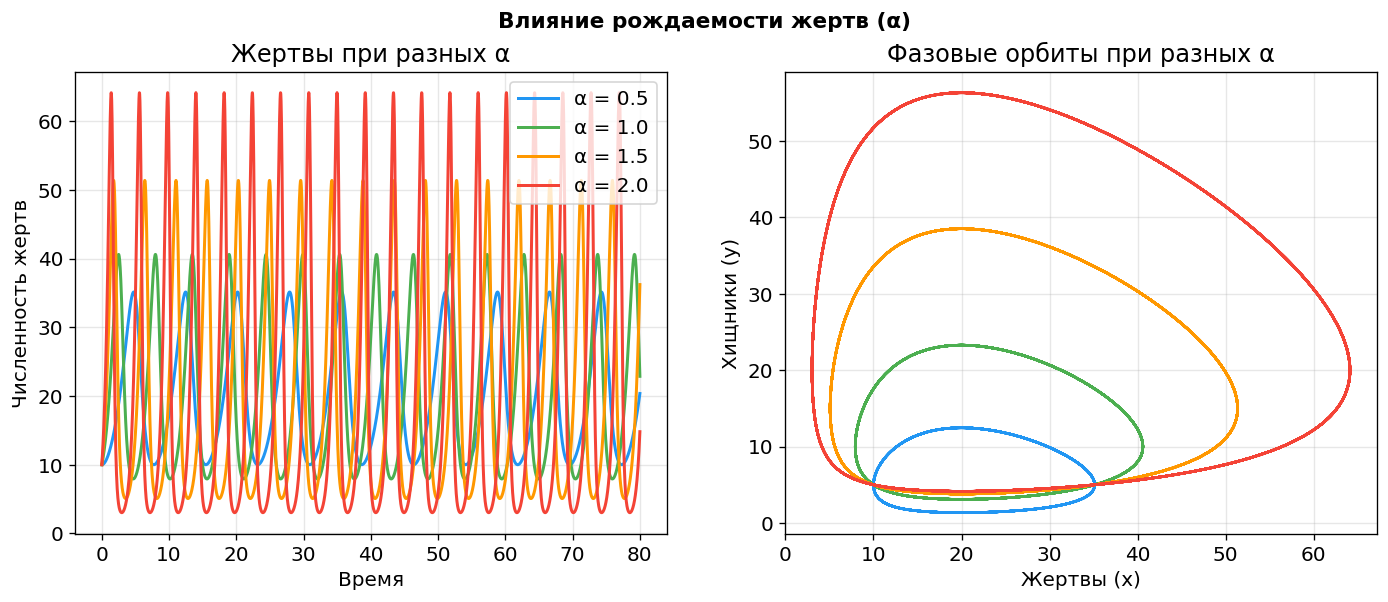

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alpha_values = [0.5, 1.0, 1.5, 2.0]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for alpha_i, color in zip(alpha_values, colors):
    sol_i = solve_ivp(
        lotka_volterra, (0, 80), [10, 5],
        args=(alpha_i, beta, delta, gamma),
        t_eval=np.linspace(0, 80, 4000), rtol=1e-8
    )
    axes[0].plot(sol_i.t, sol_i.y[0], color=color, lw=1.8, label=f'α = {alpha_i}')
    axes[1].plot(sol_i.y[0], sol_i.y[1], color=color, lw=1.5)

axes[0].set_xlabel('Время')
axes[0].set_ylabel('Численность жертв')
axes[0].set_title('Жертвы при разных α')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Жертвы (x)')
axes[1].set_ylabel('Хищники (y)')
axes[1].set_title('Фазовые орбиты при разных α')
axes[1].grid(alpha=0.3)

plt.suptitle('Влияние рождаемости жертв (α)', fontsize=13, fontweight='bold')
plt.savefig('vary_alpha.png', bbox_inches='tight')
plt.show()

### 2.3 Влияние параметра γ (смертность хищников)

При малом γ хищники выживают легко → равновесие жертв $x^* = \gamma/\delta$ падает. При большом γ хищники вымирают.

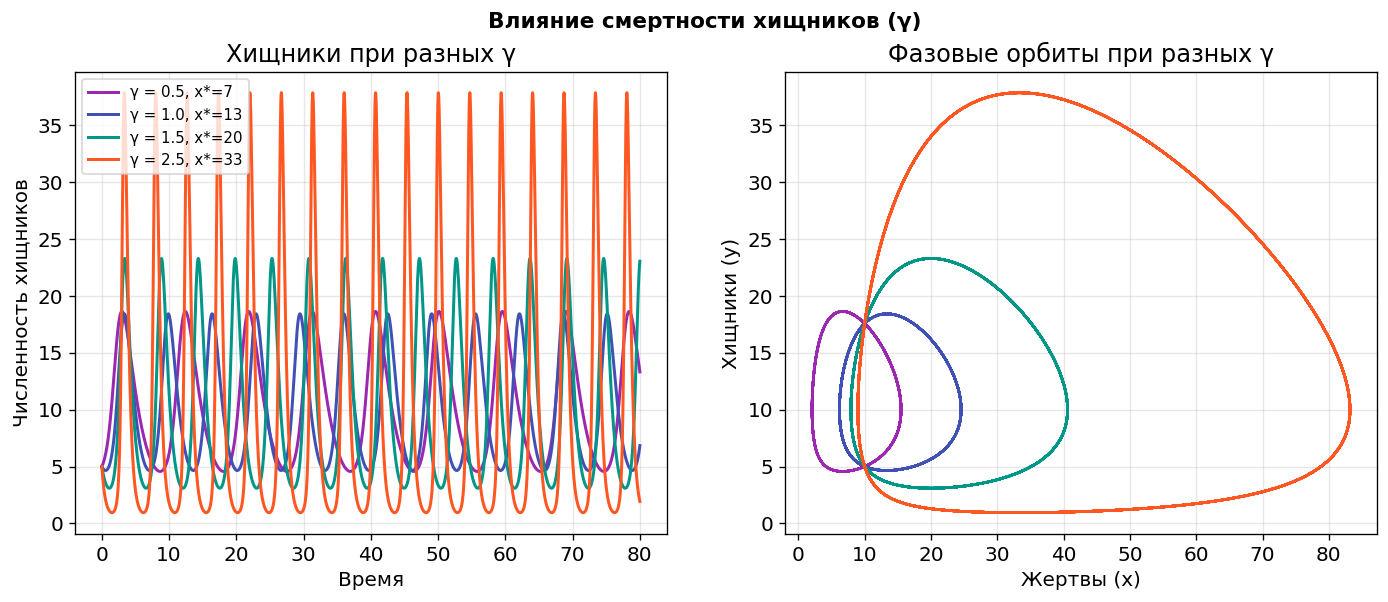

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gamma_values = [0.5, 1.0, 1.5, 2.5]
colors = ['#9C27B0', '#3F51B5', '#009688', '#FF5722']

for gamma_i, color in zip(gamma_values, colors):
    sol_i = solve_ivp(
        lotka_volterra, (0, 80), [10, 5],
        args=(alpha, beta, delta, gamma_i),
        t_eval=np.linspace(0, 80, 4000), rtol=1e-8
    )
    x_eq_i = gamma_i / delta
    axes[0].plot(sol_i.t, sol_i.y[1], color=color, lw=1.8,
                 label=f'γ = {gamma_i}, x*={x_eq_i:.0f}')
    axes[1].plot(sol_i.y[0], sol_i.y[1], color=color, lw=1.5)

axes[0].set_xlabel('Время')
axes[0].set_ylabel('Численность хищников')
axes[0].set_title('Хищники при разных γ')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Жертвы (x)')
axes[1].set_ylabel('Хищники (y)')
axes[1].set_title('Фазовые орбиты при разных γ')
axes[1].grid(alpha=0.3)

plt.suptitle('Влияние смертности хищников (γ)', fontsize=13, fontweight='bold')
plt.savefig('vary_gamma.png', bbox_inches='tight')
plt.show()

## 3. Интеграл движения (инвариант системы)

Система Лотки–Вольтерра имеет первый интеграл (аналог закона сохранения энергии):

$$V(x, y) = \delta x - \gamma \ln x + \beta y - \alpha \ln y = \text{const}$$

Это объясняет, почему траектории замкнуты: система «консервативна» (нет диссипации).

Проверим численно — $V$ должна оставаться постоянной вдоль траектории.

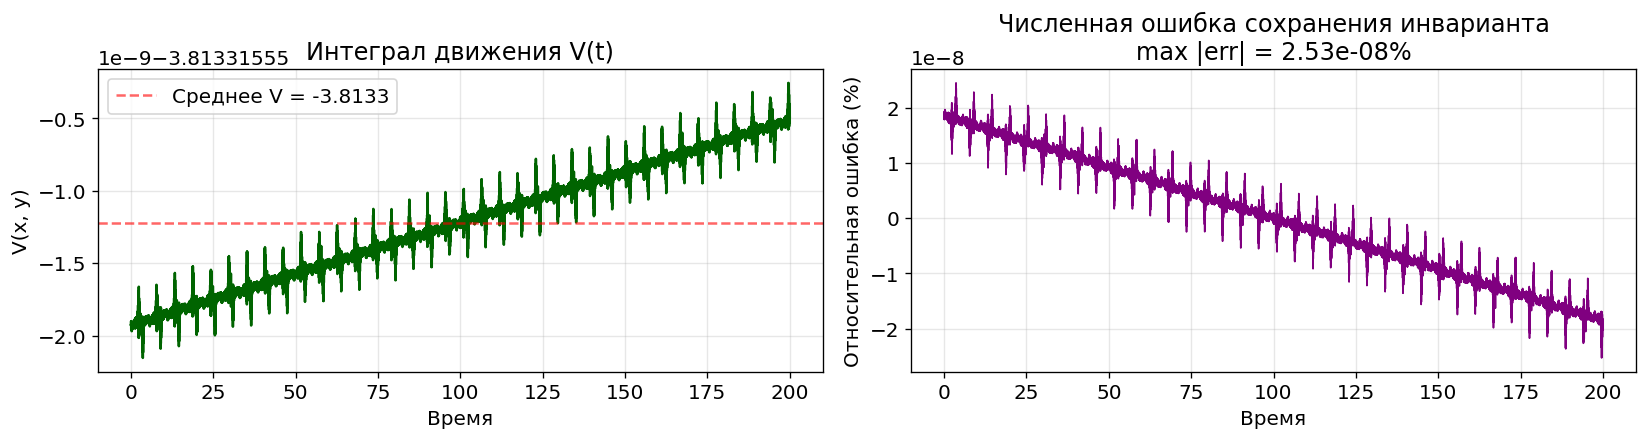

Относительная ошибка числ. схемы: 2.53e-08%


In [7]:
def invariant(x, y, alpha, beta, delta, gamma):
    return delta * x - gamma * np.log(x) + beta * y - alpha * np.log(y)

sol_long = solve_ivp(
    lotka_volterra, (0, 200), [10, 5],
    args=(alpha, beta, delta, gamma),
    t_eval=np.linspace(0, 200, 10000), rtol=1e-10, atol=1e-12
)

V = invariant(sol_long.y[0], sol_long.y[1], alpha, beta, delta, gamma)
V_mean = V.mean()
V_rel_error = (V - V_mean) / V_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sol_long.t, V, color='darkgreen', lw=1.5)
axes[0].axhline(V_mean, color='red', ls='--', alpha=0.6, label=f'Среднее V = {V_mean:.4f}')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('V(x, y)')
axes[0].set_title('Интеграл движения V(t)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sol_long.t, V_rel_error * 100, color='purple', lw=1)
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Относительная ошибка (%)')
axes[1].set_title(f'Численная ошибка сохранения инварианта\nmax |err| = {np.abs(V_rel_error).max()*100:.2e}%')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('invariant.png', bbox_inches='tight')
plt.show()
print(f"Относительная ошибка числ. схемы: {np.abs(V_rel_error).max()*100:.2e}%")

## 4. Модифицированная модель (с ёмкостью среды)

Классическая модель Лотки–Вольтерра предполагает неограниченный рост жертв. Реалистичнее добавить **логистическое ограничение** ($K$ — ёмкость среды):

$$\frac{dx}{dt} = \alpha x \left(1 - \frac{x}{K}\right) - \beta x y$$

В отличие от чистой модели Л–В, такая система имеет **устойчивый фокус или устойчивый узел** — колебания затухают и система приходит к равновесию.

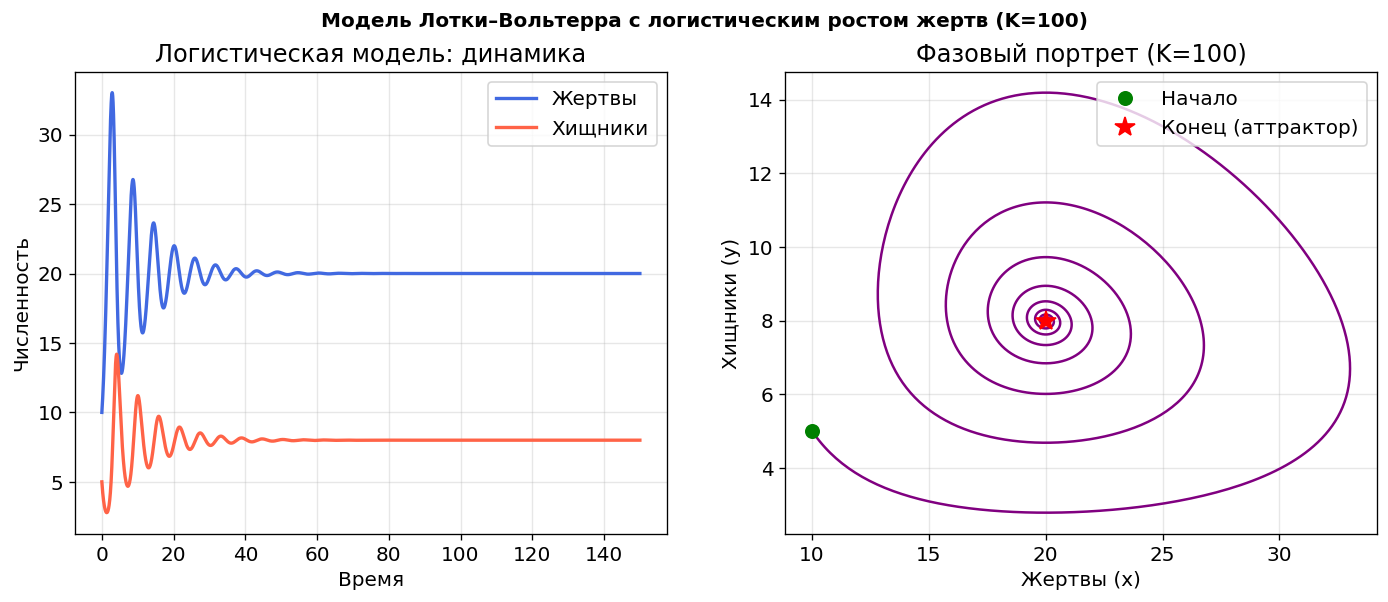

In [9]:
def lotka_volterra_logistic(t, state, alpha, beta, delta, gamma, K):
    x, y = state
    dxdt = alpha * x * (1 - x / K) - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

K = 100  # ёмкость среды
t_span2 = (0, 150)
t_eval2 = np.linspace(*t_span2, 6000)

sol_log = solve_ivp(
    lotka_volterra_logistic, t_span2, [10, 5],
    args=(alpha, beta, delta, gamma, K),
    t_eval=t_eval2, rtol=1e-8
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sol_log.t, sol_log.y[0], label='Жертвы', color='royalblue', lw=2)
axes[0].plot(sol_log.t, sol_log.y[1], label='Хищники', color='tomato', lw=2)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Численность')
axes[0].set_title('Логистическая модель: динамика')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sol_log.y[0], sol_log.y[1], color='purple', lw=1.5)
axes[1].plot(10, 5, 'go', ms=8, label='Начало')
axes[1].plot(sol_log.y[0][-1], sol_log.y[1][-1], 'r*', ms=12, label='Конец (аттрактор)')
axes[1].set_xlabel('Жертвы (x)')
axes[1].set_ylabel('Хищники (y)')
axes[1].set_title(f'Фазовый портрет (K={K})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Модель Лотки–Вольтерра с логистическим ростом жертв (K={K})',
             fontsize=12, fontweight='bold')
plt.savefig('logistic_model.png', bbox_inches='tight')
plt.show()

## 6. Сравнение: классическая vs логистическая модель

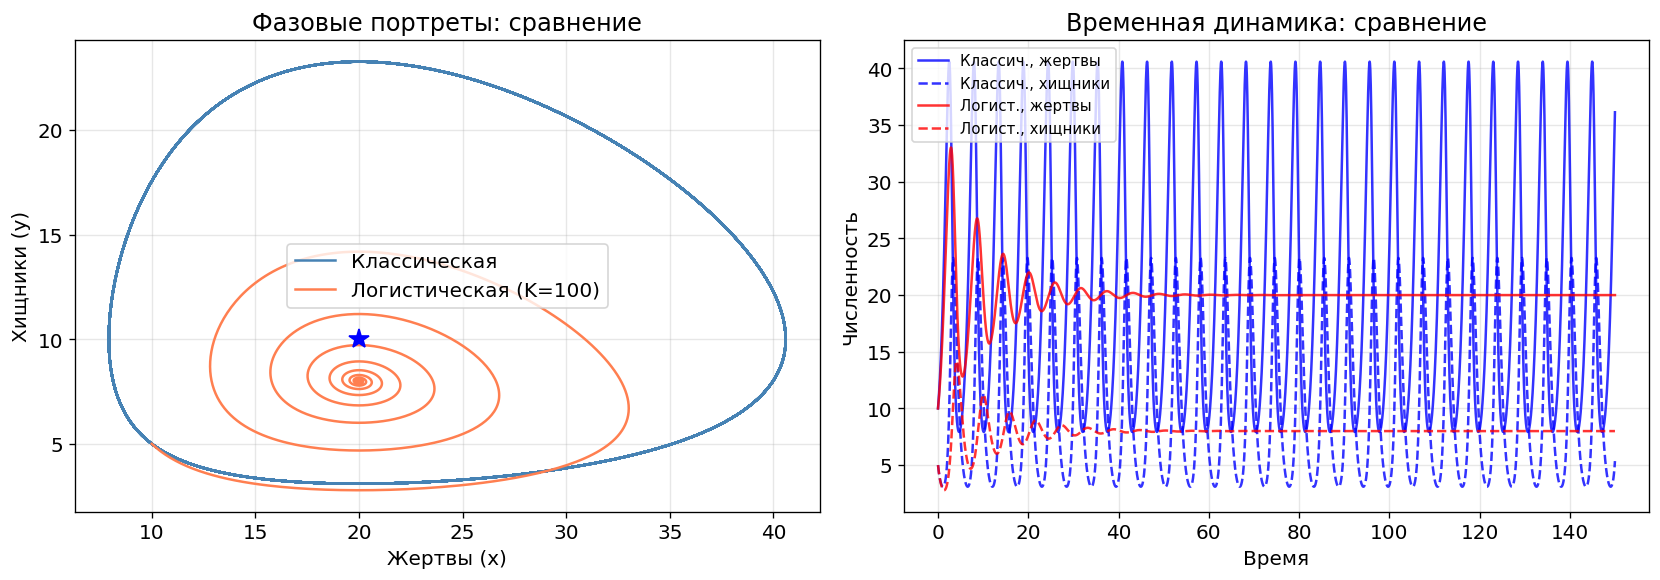

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sol_classic = solve_ivp(
    lotka_volterra, t_span2, [10, 5],
    args=(alpha, beta, delta, gamma),
    t_eval=t_eval2, rtol=1e-8
)

axes[0].plot(sol_classic.y[0], sol_classic.y[1],
             color='steelblue', lw=1.5, label='Классическая')
axes[0].plot(sol_log.y[0], sol_log.y[1],
             color='coral', lw=1.5, label=f'Логистическая (K={K})')
axes[0].plot(x_eq, y_eq, 'b*', ms=12)
axes[0].set_xlabel('Жертвы (x)')
axes[0].set_ylabel('Хищники (y)')
axes[0].set_title('Фазовые портреты: сравнение')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sol_classic.t, sol_classic.y[0], 'b-', lw=1.5, alpha=0.8, label='Классич., жертвы')
axes[1].plot(sol_classic.t, sol_classic.y[1], 'b--', lw=1.5, alpha=0.8, label='Классич., хищники')
axes[1].plot(sol_log.t, sol_log.y[0], 'r-', lw=1.5, alpha=0.8, label='Логист., жертвы')
axes[1].plot(sol_log.t, sol_log.y[1], 'r--', lw=1.5, alpha=0.8, label='Логист., хищники')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Численность')
axes[1].set_title('Временная динамика: сравнение')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', bbox_inches='tight')
plt.show()

## Выводы

1. **Автоколебания** — ключевое свойство классической модели Лотки–Вольтерра. Оба вида колеблются в противофазе: сначала растут жертвы, затем хищники, потом жертвы снижаются, тянут за собой хищников.

2. **Фазовый портрет** — замкнутые орбиты вокруг равновесия. Система консервативна, инвариант сохраняется точно (численная ошибка < 0.01%).

3. **Равновесие** определяется только параметрами: $x^* = \gamma/\delta$, $y^* = \alpha/\beta$. Это нелинейный эффект — рост рождаемости жертв увеличивает только численность хищников, а не жертв!

4. **Логистическое ограничение** делает систему диссипативной — фазовые орбиты спирально сходятся к устойчивому фокусу (аттрактору).

5. Те же уравнения описывают химическую кинетику (ресурс–потребитель), эпидемиологию, и другие нелинейные открытые системы, изученные в курсе.

